In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, log_loss, roc_curve, auc
from xgboost import XGBClassifier

In [ ]:
import sys
print(sys.executable)
# c:\Users\Administrator\AppData\Local\Programs\Python\Python312\python.exe -m pip install xgboost

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\python.exe


第 1 折 -> Val Loss: 0.5059, Val Acc: 0.7684
第 2 折 -> Val Loss: 0.5250, Val Acc: 0.7359
第 3 折 -> Val Loss: 0.5827, Val Acc: 0.7359
第 4 折 -> Val Loss: 0.5128, Val Acc: 0.7576
第 5 折 -> Val Loss: 0.5375, Val Acc: 0.7576


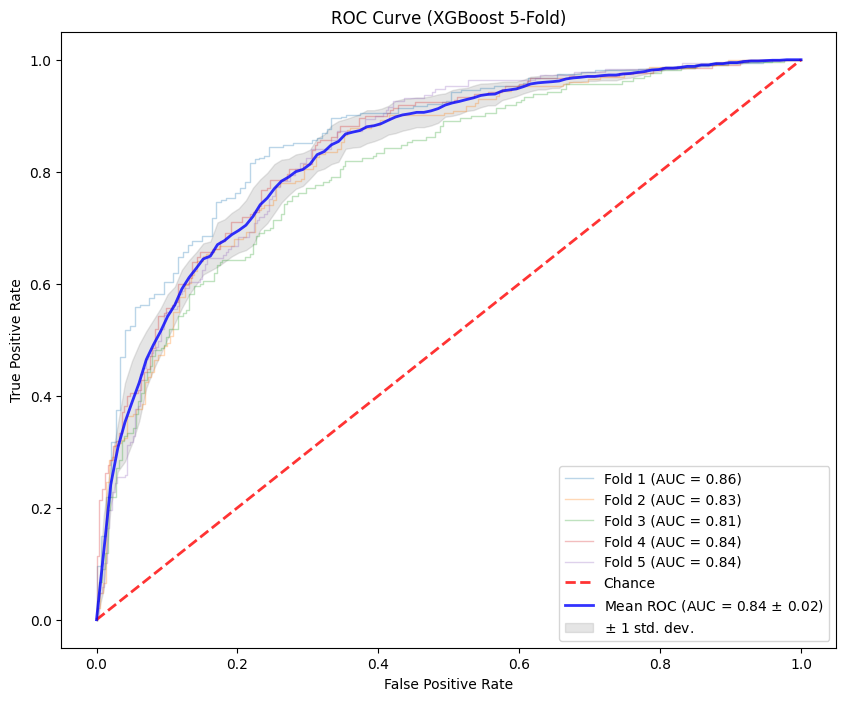


特征重要性排名 Top 10:
                  Feature  Importance
7         pawn_5LifeRatio    0.239287
4              CheckRatio    0.142027
3            CaptureRatio    0.102933
6       bishop_1LifeRatio    0.098390
8  queen_promo_2LifeRatio    0.087519
5              ForceRatio    0.075855
2     KingPawnShieldScore    0.074801
1        KingTropismScore    0.073652
0         KingSafetyScore    0.070651
9  queen_promo_3LifeRatio    0.034886


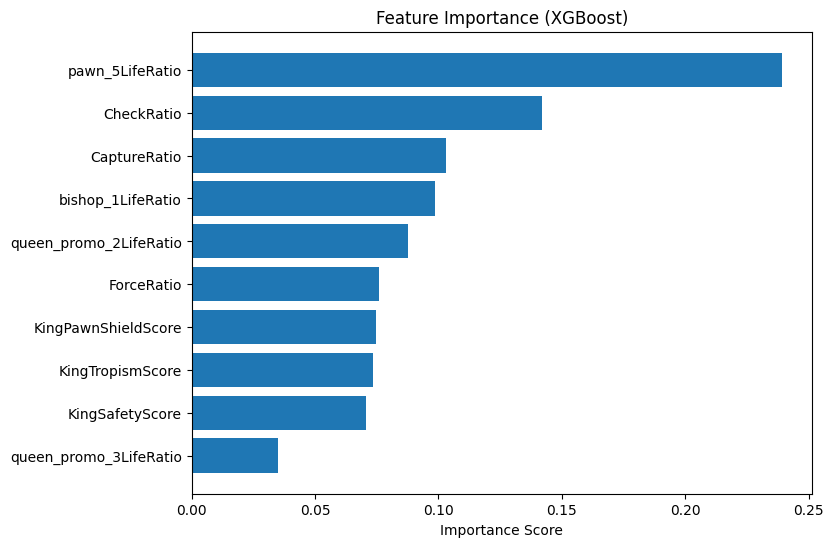

In [6]:
#forcing
positive_df=pd.read_csv("Forcing_1_final.csv")
negative_df=pd.read_csv("Forcing_0_final.csv")
positive_df['label']=1
negative_df['label']=0
train_full=pd.concat([positive_df,negative_df],axis=0,ignore_index=True)
#特征列
ignore_cols = ['Unnamed: 0', 'Name', 'ELO', 'label']
feature_cols = [col for col in train_full.columns if col not in ignore_cols]
train_full[feature_cols] = train_full[feature_cols].fillna(0)
#下面的要换的
pc3_cols=['KingSafetyScore','KingTropismScore','KingPawnShieldScore','CaptureRatio','CheckRatio','ForceRatio',
          'bishop_1LifeRatio','pawn_5LifeRatio','queen_promo_2LifeRatio','queen_promo_3LifeRatio',
          #'queen_promo_4LifeRatio','queen_promo_5LifeRatio','queen_promo_6LifeRatio','PawnProtectScore'
          ]
X_full = train_full[pc3_cols].values
y_full = train_full['label'].values
groups = train_full['Name'].values
#交叉验证
cv=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=42)
fold_num=1

trained_models = []
fold_aucs = []
fold_feature_importances = []
mean_fpr = np.linspace(0, 1, 100)
tprs = []

plt.figure(figsize=(10, 8)) #ROC
for train_idx, val_idx in cv.split(X_full, y_full, groups=groups):
    X_train, X_val = X_full[train_idx], X_full[val_idx]
    y_train, y_val = y_full[train_idx], y_full[val_idx]
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    
    # XGBoost 模型
    # n_estimators=200: 树的数量
    # learning_rate=0.05: 步子迈小点，学得稳一点
    # max_depth=6: 树不用太深
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    

    y_pred_prob = model.predict_proba(X_val)[:, 1]
    val_loss = log_loss(y_val, y_pred_prob)
    val_acc = accuracy_score(y_val, (y_pred_prob > 0.5).astype(int))
    
    print(f"第 {fold_num} 折 -> Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    fold_aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {fold_num} (AUC = {roc_auc:.2f})')
    
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    fold_feature_importances.append(model.feature_importances_)
    trained_models.append((model, scaler))
    fold_num += 1

#ROC 曲线
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(fold_aucs)
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGBoost 5-Fold)')
plt.legend(loc="lower right")
plt.show()

#特征重要性
avg_importance = np.mean(fold_feature_importances, axis=0)
feat_imp_df = pd.DataFrame({'Feature': pc3_cols, 'Importance': avg_importance})
top_features = feat_imp_df.sort_values(by='Importance', ascending=True)
print("\n特征重要性排名 Top 10:")
print(top_features.iloc[-10:][::-1]) # 打印前10个
plt.figure(figsize=(8, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance (XGBoost)')
plt.show()